In [1]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
from geopy.distance import geodesic
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import seaborn as sns
from scipy import stats

# from jupyterthemes import jtplot
# jtplot.style()


In [2]:
# 计算弯曲度的函数
def calculate_sinuosity(latitudes, longitudes):
    # 计算路径的实际长度
    path_length = 0
    for i in range(1, len(latitudes)):
        point1 = (latitudes[i-1], longitudes[i-1])
        point2 = (latitudes[i], longitudes[i])
        path_length += geodesic(point1, point2).km
    
    # 计算起点和终点的直线距离
    start_point = (latitudes[0], longitudes[0])
    end_point = (latitudes[-1], longitudes[-1])
    straight_line_distance = geodesic(start_point, end_point).km
    
    # 计算弯曲度
    sinuosity = path_length / straight_line_distance
    return sinuosity

In [3]:
ds = xr.open_dataset('D:/data/GFDL/CMCC/CMCC-CM2-VHR4/TC-NH_TRACK_CMCC-CM2-VHR4_highresSST-present_r1i1p1f1_gn_19500101-20141231.nc')

In [4]:
min_lon = 100
max_lon = 180
min_lat = 0
max_lat = 30

In [5]:
import pandas as pd
import numpy as np
import cftime

ressinuosity = []
resfrequency = []

for yearlis in range(1982, 2015):

    tracks_year = []

    # 遍历所有台风
    for i in range(ds.sizes['tracks']):
        # 获取轨迹的起始索引和轨迹数据
        start_index = ds['FIRST_PT'].isel(tracks=i).item()
        num_pts = ds['NUM_PTS'].isel(tracks=i).item()
        
        # 获取轨迹的时间和经纬度
        latitudes = ds['lat'].isel(record=slice(start_index, start_index + num_pts)).values
        longitudes = ds['lon'].isel(record=slice(start_index, start_index + num_pts)).values
        times = ds['time'].isel(record=slice(start_index, start_index + num_pts)).values

        # ✅ 自动识别 cftime 类型并转换为 pandas.Timestamp
        if isinstance(times[0], cftime.DatetimeNoLeap) or isinstance(times[0], cftime.Datetime360Day) or isinstance(times[0], cftime.DatetimeGregorian):
            times = [pd.Timestamp(t.strftime("%Y-%m-%d %H:%M:%S")) for t in times]
        else:
            times = pd.to_datetime(times)

        # 检查是否经过西北太平洋
        is_nw_pacific = False
        for lat, lon in zip(latitudes, longitudes):
            if min_lon <= lon <= max_lon and min_lat <= lat <= max_lat:
                is_nw_pacific = True
                break  # 一旦发现经过西北太平洋，停止循环
        
        if is_nw_pacific:
            # 获取轨迹的第一个时间点和最后一个时间点
            first_time_dt = times[0]
            last_time_dt = times[-1]
            
            # 计算持续时间（小时）
            duration = (last_time_dt - first_time_dt).total_seconds() / 3600  
            
            # 获取风速数据（单位 m/s）
            wind_speeds = ds['sfcWind'].isel(record=slice(start_index, start_index + num_pts)).values  
            
            # 计算最大风速（单位：kt）
            max_wind_speed = np.max(wind_speeds) * 1.9438  
            
            # ✅ 筛选条件
            if first_time_dt.year == yearlis and 7 <= first_time_dt.month <= 10 and duration > 48 and max_wind_speed > 17.2:
                track_id = ds['TRACK_ID'].isel(tracks=i).item()
                track_data = ds.isel(record=slice(start_index, start_index + num_pts))
                
                tracks_year.append({
                    'track_id': track_id,
                    'start_time': first_time_dt,
                    'duration': duration,
                    'max_wind_speed': max_wind_speed,
                    'start_lat': latitudes[0],
                    'start_lon': longitudes[0],
                    'data': track_data
                })

    # 每年符合条件的台风数量
    resfrequency.append(len(tracks_year))

    # 计算弯曲度
    sinuosity_values = []
    for track in tracks_year:
        latitudes = track['data']['lat'].values
        longitudes = track['data']['lon'].values
        
        sinuosity = calculate_sinuosity(latitudes, longitudes)

        if sinuosity < 5:
            sinuosity_values.append(sinuosity)

    # 年平均弯曲度
    average_sinuosity = np.mean(sinuosity_values) if sinuosity_values else 0
    ressinuosity.append(average_sinuosity)

# ✅ 输出结果
for year, freq, sinu in zip(range(1982, 2015), resfrequency, ressinuosity):
    print(f"{year}年7-10月：符合条件的台风数={freq}，平均弯曲度={sinu:.3f}")


1982年7-10月：符合条件的台风数=24，平均弯曲度=1.822
1983年7-10月：符合条件的台风数=14，平均弯曲度=1.797
1984年7-10月：符合条件的台风数=34，平均弯曲度=1.771
1985年7-10月：符合条件的台风数=23，平均弯曲度=2.026
1986年7-10月：符合条件的台风数=12，平均弯曲度=1.831
1987年7-10月：符合条件的台风数=14，平均弯曲度=1.783
1988年7-10月：符合条件的台风数=23，平均弯曲度=1.717
1989年7-10月：符合条件的台风数=18，平均弯曲度=1.711
1990年7-10月：符合条件的台风数=28，平均弯曲度=2.005
1991年7-10月：符合条件的台风数=33，平均弯曲度=1.877
1992年7-10月：符合条件的台风数=25，平均弯曲度=1.792
1993年7-10月：符合条件的台风数=35，平均弯曲度=1.724
1994年7-10月：符合条件的台风数=27，平均弯曲度=1.775
1995年7-10月：符合条件的台风数=19，平均弯曲度=1.771
1996年7-10月：符合条件的台风数=17，平均弯曲度=1.481
1997年7-10月：符合条件的台风数=25，平均弯曲度=1.986
1998年7-10月：符合条件的台风数=15，平均弯曲度=1.593
1999年7-10月：符合条件的台风数=13，平均弯曲度=1.669
2000年7-10月：符合条件的台风数=28，平均弯曲度=1.754
2001年7-10月：符合条件的台风数=25，平均弯曲度=1.509
2002年7-10月：符合条件的台风数=17，平均弯曲度=1.905
2003年7-10月：符合条件的台风数=25，平均弯曲度=1.866
2004年7-10月：符合条件的台风数=24，平均弯曲度=1.613
2005年7-10月：符合条件的台风数=15，平均弯曲度=1.943
2006年7-10月：符合条件的台风数=17，平均弯曲度=1.550
2007年7-10月：符合条件的台风数=29，平均弯曲度=1.792
2008年7-10月：符合条件的台风数=9，平均弯曲度=1.556
2009年7-10月：符合条件的台风数=25，平均弯曲度=1.731
2010年7-10月：符合条件的台风数=9

In [7]:
ressinuosity

[np.float64(1.8223753249124184),
 np.float64(1.7967861637084144),
 np.float64(1.7714284758086738),
 np.float64(2.0256414701735217),
 np.float64(1.8312417166846322),
 np.float64(1.7832122889059008),
 np.float64(1.717233999728584),
 np.float64(1.7107516780347765),
 np.float64(2.0050002542273107),
 np.float64(1.876610879116768),
 np.float64(1.7919215666162394),
 np.float64(1.7239489547721703),
 np.float64(1.7754541677496112),
 np.float64(1.7714811684753682),
 np.float64(1.481058025223922),
 np.float64(1.9855098971777803),
 np.float64(1.5933886519436549),
 np.float64(1.6688675746767412),
 np.float64(1.7541297882237976),
 np.float64(1.509447903665187),
 np.float64(1.90511628314474),
 np.float64(1.8657229295400393),
 np.float64(1.6130908200391918),
 np.float64(1.9433695364598904),
 np.float64(1.5496447806775073),
 np.float64(1.7923929304646926),
 np.float64(1.5562426021447242),
 np.float64(1.7311113782580605),
 np.float64(1.9410503786398776),
 np.float64(1.5757473541967117),
 np.float64(1.70

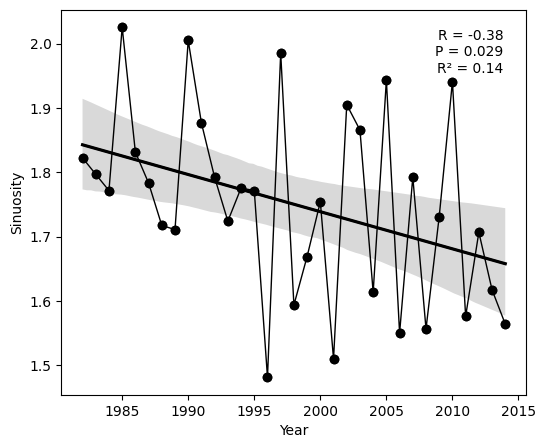

R: -0.3806843957705935
P: 0.028846164537189852
R2: 0.14492060918322186


In [6]:
years = np.arange(1982, 2015)
x=years
y=ressinuosity
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
textstr = f"R = {r_value:.2f}\nP = {p_value:.3f}\nR² = {r_squared:.2f}"
ax.text(0.95, 0.95, textstr, transform=ax.transAxes,
        fontsize=10, va='top', ha='right')
plt.xlabel('Year')
plt.ylabel('Sinuosity')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

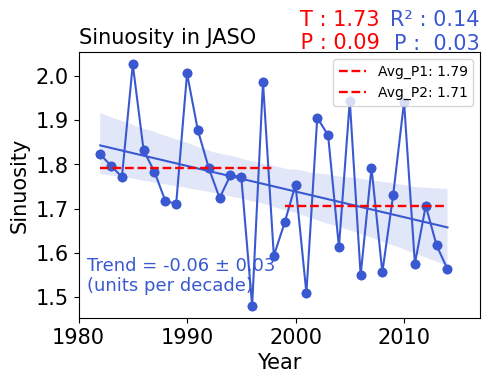

In [18]:
fig, axes = plt.subplots(1,1, figsize=(5, 4))
ax=axes
split_index=17

color1='#3A59D1'
color2=color1
color3='r'



data=ressinuosity
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1,linewidth=1.5)

x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--',linewidth=1.7, label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--',linewidth=1.7,
        label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Sinuosity', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Sinuosity in JASO',loc='left',fontsize=15)
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.02,0.1,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color1,
       transform=ax.transAxes)

ax.text(0.75, 1.16, f'T : {t_stat:.2f}\n P : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color1, transform=ax.transAxes)
ax.text(1, 1.07, f'P :  {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color1, transform=ax.transAxes)



# 设置横坐标范围和刻度
ax.set_xlim(1980, 2017)
ax.set_xticks(np.arange(1980, 2020, 10))
ax.set_xticklabels(np.arange(1980, 2020, 10), fontsize=15)

plt.tight_layout()
plt.savefig("04CMCC.pdf",transparent = True)


plt.show()

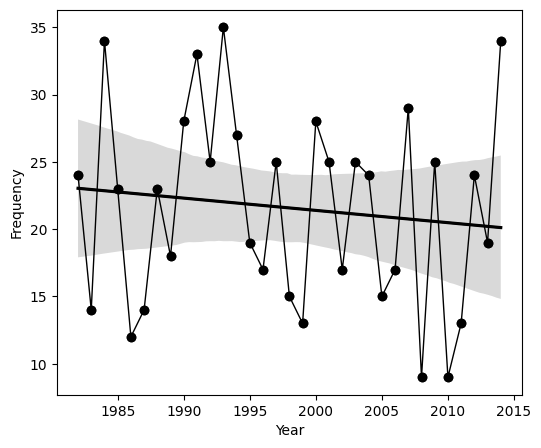

R: -0.12062082241304513
P: 0.5037225024573383
R2: 0.01454938279959937


In [8]:
years = np.arange(1982, 2015)
x=years
y=resfrequency
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def plot_change_data(years, data, ylabel, title, split_index):
    """
    根据输入的年份、数据、分割点、纵坐标标签和图表标题绘制折线图，并标注前后平均值横线。
    
    Parameters:
    years (array-like): 年份序列。
    data (array-like): 对应年份的数值数据。
    ylabel (str): 纵坐标的标签。
    title (str): 图表的标题。
    split_index (int): 数据分割点，用于划分前后部分。
    """
    # 计算分割点之前和之后的平均值
    avg_prior = np.mean(data[:split_index])
    avg_post = np.mean(data[split_index:])
    
    # 绘制数据点及连线
    plt.plot(years, data, '-o', color='red')
    
    # 绘制分割点之前数据的平均值横线
    plt.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
    
    # 绘制分割点之后数据的平均值横线
    plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
    
    # 添加坐标标签和标题
    plt.xlabel('Year', fontsize=15)
    plt.ylabel(ylabel, fontsize=15)
    plt.title(title,loc='left',fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    
    
    # 添加图例
    plt.legend(loc=1)

    
    P1 = data[:split_index]
    P2 =  data[split_index:]

    # 执行独立样本t检验，默认假设方差不等
    t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)

#     print(f"t-statistic: {t_stat}")
#     print(f"p-value: {p_value}")
    
    
    
#     x=years
#     y=data
#     #........................................................................................................   
    
#     # 计算线性回归
#     slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
#     # 计算 R 方
#     r_squared = r_value ** 2
#     ax = sns.regplot(x=x, y=y, ci=95,color='r')
# #     ax = sns.regplot(x=x, y=y, ci=95, color='r', scatter_kws={'s': 5}, line_kws={'linewidth': 1})
#     # 绘制散点图和回归线
#     plt.plot(x,y, alpha=1, linewidth=1.5,color='r')
# #     plt.plot(x, y, color='r', marker='o', linestyle='-', linewidth=1, markersize=5)

# #     plt.plot(x, intercept + slope * np.array(x), 'r')
#     print('R:',r_value)
#     print('P:', p_value)
#     print('R2:', r_squared)
    plt.title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
#     plt.text(1992, 1.05, f"Slope: {slope:.3f} ± {std_err:.3f}  per decade", fontsize=15, color='black')
    
    plt.show()
# split_index = 16  # 设置分割点为前16年和后24年
# plot_change_data(years, tomecur_totle, 'dist/km', 'Dist over Years', 17)


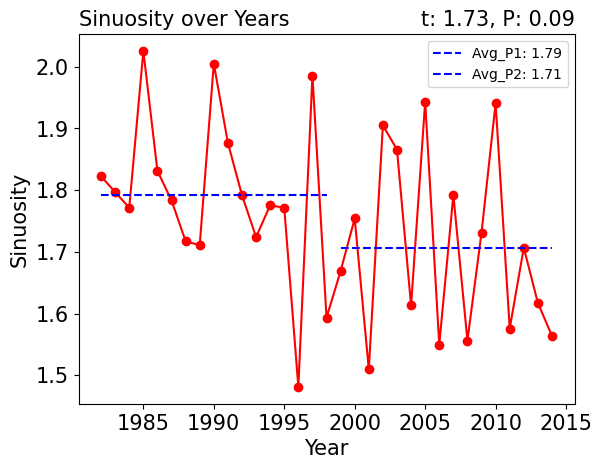

In [10]:
plot_change_data(years, ressinuosity, 'Sinuosity', 'Sinuosity over Years', 17)

In [11]:
# def sk(data):
#     n=len(data)
#     Sk     = [0]
#     UFk    = [0]
#     s      =  0
#     E      = [0]
#     Var    = [0]
#     for i in range(1,n):
#         for j in range(i):
#             if data[i] > data[j]:
#                 s = s+1
#             else:
#                 s = s+0
#         Sk.append(s)
#         E.append((i+1)*(i+2)/4 )                     # Sk[i]的均值
#         Var.append((i+1)*i*(2*(i+1)+5)/72 )            # Sk[i]的方差
#         UFk.append((Sk[i]-E[i])/np.sqrt(Var[i]))
#     UFk=np.array(UFk)
#     return UFk

# def MK(data, a):
#     ufk = sk(data)  # 顺序列
#     ubk1 = sk(data[::-1])  # 逆序列
#     ubk = -ubk1[::-1]  # 逆转逆序列
    
#     # 创建年份范围作为横坐标
#     years = np.arange(1982, 2015)  # 生成1982到2023年的数组
    
#     # 输出突变点的位置
#     p = []
#     u = ufk - ubk
#     for i in range(1, len(ufk)):
#         if u[i-1] * u[i] < 0:
#             p.append(i)
#     if p:
#         print("突变点位置：", p)
#     else:
#         print("未检测到突变点")
    
#     # 画图
#     conf_interval = stats.norm.interval(a, loc=0, scale=1)  # 获取置信区间
#     plt.rcParams['axes.unicode_minus'] = False  # 解决负号不显示问题
#     plt.figure(figsize=(10, 5))
    
#     # 使用年份作为横坐标
#     plt.plot(years, ufk, label='UFk', color='r')
#     plt.plot(years, ubk, label='UBk', color='b')
    
#     plt.ylabel('UFk-UBk', fontsize=15)
#     x_lim = plt.xlim()
#     plt.ylim([-6, 7])
    
#     # 绘制置信区间线
#     plt.plot(x_lim, [conf_interval[0], conf_interval[0]], '--', color='r', label='95% Confidence Interval')
#     plt.plot(x_lim, [conf_interval[1], conf_interval[1]], '--', color='r')
#     plt.axhline(0, ls="--", c="k")
    
#     # 图例设置
#     plt.legend(loc='upper center', frameon=False, ncol=3, fontsize=15)
#     plt.xticks(fontsize=15)
#     plt.yticks(fontsize=15)
#     plt.xlabel('Year', fontsize=15)
#     plt.show()


In [12]:
# MK(ressinuosity, 0.95)

In [13]:





# proj = ccrs.PlateCarree(180)
# fig = plt.figure(figsize=(10, 8))
# ax = plt.axes(projection=proj)
# ax.set_extent([100, 180, 0, 60])
# ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
# ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)



# for yearlis in range(1982, 2015):

#     tracks_year = []

#     # 遍历所有台风
#     for i in range(ds.sizes['tracks']):
#         # 获取轨迹的起始索引和轨迹数据
#         start_index = ds['FIRST_PT'].isel(tracks=i).item()
#         num_pts = ds['NUM_PTS'].isel(tracks=i).item()
        
#         # 获取轨迹的时间和经纬度
#         latitudes = ds['lat'].isel(record=slice(start_index, start_index + num_pts)).values
#         longitudes = ds['lon'].isel(record=slice(start_index, start_index + num_pts)).values
#         times = ds['time'].isel(record=slice(start_index, start_index + num_pts)).values

#         # ✅ 自动识别 cftime 类型并转换为 pandas.Timestamp
#         if isinstance(times[0], cftime.DatetimeNoLeap) or isinstance(times[0], cftime.Datetime360Day) or isinstance(times[0], cftime.DatetimeGregorian):
#             times = [pd.Timestamp(t.strftime("%Y-%m-%d %H:%M:%S")) for t in times]
#         else:
#             times = pd.to_datetime(times)

#         # 检查是否经过西北太平洋
#         is_nw_pacific = False
#         for lat, lon in zip(latitudes, longitudes):
#             if min_lon <= lon <= max_lon and min_lat <= lat <= max_lat:
#                 is_nw_pacific = True
#                 break  # 一旦发现经过西北太平洋，停止循环
        
#         if is_nw_pacific:
#             # 获取轨迹的第一个时间点和最后一个时间点
#             first_time_dt = times[0]
#             last_time_dt = times[-1]
            
#             # 计算持续时间（小时）
#             duration = (last_time_dt - first_time_dt).total_seconds() / 3600  
            
#             # 获取风速数据（单位 m/s）
#             wind_speeds = ds['sfcWind'].isel(record=slice(start_index, start_index + num_pts)).values  
            
#             # 计算最大风速（单位：kt）
#             max_wind_speed = np.max(wind_speeds) * 1.9438  
            
#             # ✅ 筛选条件
#             if first_time_dt.year == yearlis and 7 <= first_time_dt.month <= 10 and duration > 48 and max_wind_speed > 17.2:
     
#                 lats=latitudes
#                 lons=longitudes
#                 ax.plot(lons, lats, '-', transform=ccrs.PlateCarree(), linewidth=1.2, alpha=0.7)

